In [ ]:
import os
import json
from datetime import datetime
import sys
sys.path.append("/home/ppathak2/Hypothesis_Generation_Active_Learning")
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [209]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [210]:
# Path to the BATS Dataset - 
PATH_BATS_dataset_root = "/home/ppathak2/Hypothesis_Generation_Active_Learning/datasets/BATS_3.0"
PATH_context_tree_output = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS_test"

In [211]:
# Let's Load the dataset in an intuitive way using pandas:
# SERIES_rel_cat = pd.S
BATS_categories = {}
for category in os.listdir(PATH_BATS_dataset_root):
    path_category = os.path.join(PATH_BATS_dataset_root, category)
    if os.path.isdir(path_category):
        category_content = [] 

        for category_type_file in tqdm(os.listdir(path_category), desc=f'Processing - {category}'):
            path_category_type_file = os.path.join(path_category, category_type_file)
            id, relation_category = category_type_file.rsplit('].')[0].split(' [')
            with open(path_category_type_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    line = line.split()
                    row = {"Id" : id, "relation-category": relation_category, 
                     "value1": line[0], "value2": line[1]}
                    category_content.append(row)
        BATS_categories[category[2:]] = category_content

DF_Inflectional_morphology = pd.DataFrame(BATS_categories['Inflectional_morphology'])
DF_Derivational_morphology = pd.DataFrame(BATS_categories['Derivational_morphology'])
DF_Encyclopedic_semantics = pd.DataFrame(BATS_categories['Encyclopedic_semantics'])
DF_Lexicographic_semantics = pd.DataFrame(BATS_categories['Lexicographic_semantics'])

Processing - 4_Lexicographic_semantics: 100%|██████████| 10/10 [00:00<00:00, 1773.57it/s]


In [212]:
DF_Lexicographic_semantics.head()

,Id,relation-category,value1,value2
0,L08,synonyms - exact,airplane,aeroplane/plane
1,L08,synonyms - exact,auto,car/automobile/motorcar
2,L08,synonyms - exact,baby,infant/babe
3,L08,synonyms - exact,bicycle,bike/wheel/cycle
4,L08,synonyms - exact,child,kid/youngster/minor/shaver/nipper/small_fry/tiddler/tike/tyke/fry/nestling


In [213]:
test_time = datetime.now().strftime("%m-%d %H:%M:%S")
PATH_output = os.path.join(PATH_context_tree_output, test_time)

In [214]:
DF_Encyclopedic_semantics["relation-category"].head()

0    UK_city - county
1    UK_city - county
2    UK_city - county
3    UK_city - county
4    UK_city - county
Name: relation-category, dtype: object

---
# Let's Test the Gender Test first:
## 1. We are using the `Encyclopedic_semantics` -> `E10 [male - female].txt`

In [215]:

value1_male = DF_Encyclopedic_semantics.where(DF_Encyclopedic_semantics['relation-category'] ==  'male - female').dropna().value1.to_list()
value2_female = DF_Encyclopedic_semantics.where(DF_Encyclopedic_semantics['relation-category'] ==  'male - female').dropna().value2.to_list()

print(value1_male)
print(value2_female)

['actor', 'batman', 'boar', 'boy', 'brother', 'buck', 'bull', 'businessman', 'chairman', 'dad', 'daddy', 'duke', 'emperor', 'father', 'fisherman', 'fox', 'gentleman', 'god', 'grandfather', 'grandpa', 'grandson', 'groom', 'headmaster', 'heir', 'hero', 'hound', 'husband', 'king', 'lion', 'man', 'manager', 'mister', 'murderer', 'nephew', 'poet', 'policeman', 'prince', 'ram', 'rooster', 'sculptor', 'sir', 'son', 'stallion', 'stepfather', 'superman', 'tiger', 'uncle', 'valet', 'waiter', 'webmaster']
['actress', 'batwoman', 'sow', 'girl', 'sister', 'doe', 'cow', 'businesswoman', 'chairwoman', 'mom/mum', 'mommy/mother/mom', 'duchess', 'empress', 'mother', 'fisherwoman', 'vixen', 'lady/gentlewoman/madam', 'goddess', 'grandmother', 'grandma', 'granddaughter', 'bride', 'headmistress', 'heiress', 'heroine', 'bitch', 'wife', 'queen', 'lioness', 'woman', 'manageress', "miss/missis/missus/mis'ess/mrs/ms/madam", 'murderess', 'niece', 'poetess', 'policewoman', 'princess', 'ewe', 'hen', 'sculptress', '

## Let's do a sample test:
1. I will load the context embedding for `depth=3`, and `num_trees=1` per keyword. Let's try the male female test.
2. I will also vizualize the results from `all_distinct_layers` of the embedding model.

In [216]:
def load_final_ctx_emb_dataset(PATH_final_emb):

    ctx_emb_dataset = {}
    for keyword in os.listdir(PATH_final_emb):
        path_keyword =  os.path.join(PATH_final_emb, keyword)
        if os.path.isdir(path_keyword):
            ctx_emb_dataset[keyword] = []
            all_jsons = os.listdir(path_keyword)
            all_jsons.remove('missing.json')
            for json_file in all_jsons:
                with open(os.path.join(path_keyword, json_file), 'r') as f:
                    data = json.load(f)
                    data = data['run_1']
                    final_emb = data['final_embedding']
                    raw_root_emb = data['raw_root_embedding']

                    # converting these into numpy arrays:
                    final_emb = np.array(final_emb)
                    raw_root_emb = np.array(raw_root_emb)

                    row = {'layer_strategy': json_file.rsplit('.json')[0].split('final_1_')[1],
                        'final_emb':final_emb,
                        'raw_root_emb': raw_root_emb}
                    ctx_emb_dataset[keyword].append(row)
    return ctx_emb_dataset

In [310]:
the2_pairs = r'''
buck	doe
businessman	businesswoman
'''
a_b, c_d = the2_pairs.strip().split('\n')
a, b = a_b.split('\t')
c, d = c_d.split('\t')

In [311]:
PATH_final_emb = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS/female-male-batch/FINAL_EMB_drugs"

ctx_emb_dataset = load_final_ctx_emb_dataset(PATH_final_emb)


# converting them 2 4 dataframes-
DF_ctx_emb_actor = pd.DataFrame(ctx_emb_dataset[a])
DF_ctx_emb_actress = pd.DataFrame(ctx_emb_dataset[b]) 
DF_ctx_emb_batman = pd.DataFrame(ctx_emb_dataset[c])
DF_ctx_emb_batwoman = pd.DataFrame(ctx_emb_dataset[d])

In [312]:
DF_ctx_emb_actor['layer_strategy']

0          first
1    first_three
2     last_three
3      first_two
4       last_two
5           last
Name: layer_strategy, dtype: object

In [313]:
DF_ctx_emb_actor['final_emb'][0].shape

(768,)

## Now, performing the `a:b :: b:c` test in each category:

In [314]:
def cosine_similarity(v1, v2):
    """
    Calculates the cosine similarity between two NumPy vectors.
    """
    dot_product = np.dot(v1, v2.T)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    if magnitude_v1 == 0 or magnitude_v2 == 0:
        return 0  # Handle cases with zero vectors to avoid division by zero

    return dot_product / (magnitude_v1 * magnitude_v2)

def run_bats_analogy_test(df_A: pd.DataFrame, df_B: pd.DataFrame,
                          df_C: pd.DataFrame, df_D: pd.DataFrame):
    layer_strategies = df_A['layer_strategy'].to_list()
    results = {}
    for layer_strategy in layer_strategies:
        results[layer_strategy] = {}

        # performing the a:b :: c:d test for final embeddings:
        a_final_emb = df_A[df_A['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        b_final_emb = df_B[df_B['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        c_final_emb = df_C[df_C['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        d_final_emb = df_D[df_D['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]

        # the predicated final embedding can be calculated using the formula - d = c + (b - a)
        predicted_d_final_emb = c_final_emb + (b_final_emb - a_final_emb)
        final_emb_cosine_sim = cosine_similarity(predicted_d_final_emb, d_final_emb)
        results[layer_strategy]['final_emb'] = {
            # 'predicted_d_final_emb': predicted_d_final_emb,
            # 'actual_d_final_emb': d_final_emb,
            'cosine_similarity': float(final_emb_cosine_sim)
        }

        # Doing the same for raw_root_emb:
        a_raw_root_emb = df_A[df_A['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        b_raw_root_emb = df_B[df_B['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        c_raw_root_emb = df_C[df_C['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        d_raw_root_emb = df_D[df_D['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        predicted_d_raw_root_emb = c_raw_root_emb + (b_raw_root_emb - a_raw_root_emb)
        raw_root_emb_cosine_sim = cosine_similarity(predicted_d_raw_root_emb, d_raw_root_emb)
        print(layer_strategy)
        results[layer_strategy]['raw_root_emb'] = {
            # 'predicted_d_raw_root_emb': predicted_d_raw_root_emb,
            # 'actual_d_raw_root_emb': d_raw_root_emb,
            'cosine_similarity': float(raw_root_emb_cosine_sim)
        }
    return results

In [315]:
def plot_cosine_similarities(results, title):
    layer_strategies = list(results.keys())
    final_emb_cosine_similarities = [results[strategy]['final_emb']['cosine_similarity'] for strategy in layer_strategies]
    raw_root_emb_cosine_similarities = [results[strategy]['raw_root_emb']['cosine_similarity'] for strategy in layer_strategies]

    x = range(len(layer_strategies))
    width = 0.2
    # need to make sure the ticks on y-axis is 0.2 and is between 0 to 1:
    
    plt.figure(figsize=(10, 6))
    plt.bar(x, final_emb_cosine_similarities, width, label='Final Context Embedding')
    plt.bar([i + width for i in x], raw_root_emb_cosine_similarities, width, label='Raw Root Embedding')

    plt.xlabel('Layer Strategies')
    plt.ylabel('Cosine Similarity')
    plt.title(title)
    plt.xticks([i + width/2 for i in x], layer_strategies, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

first
first_three
last_three
first_two
last_two
last


/tmp/ipykernel_4127476/3702771147.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'cosine_similarity': float(raw_root_emb_cosine_sim)


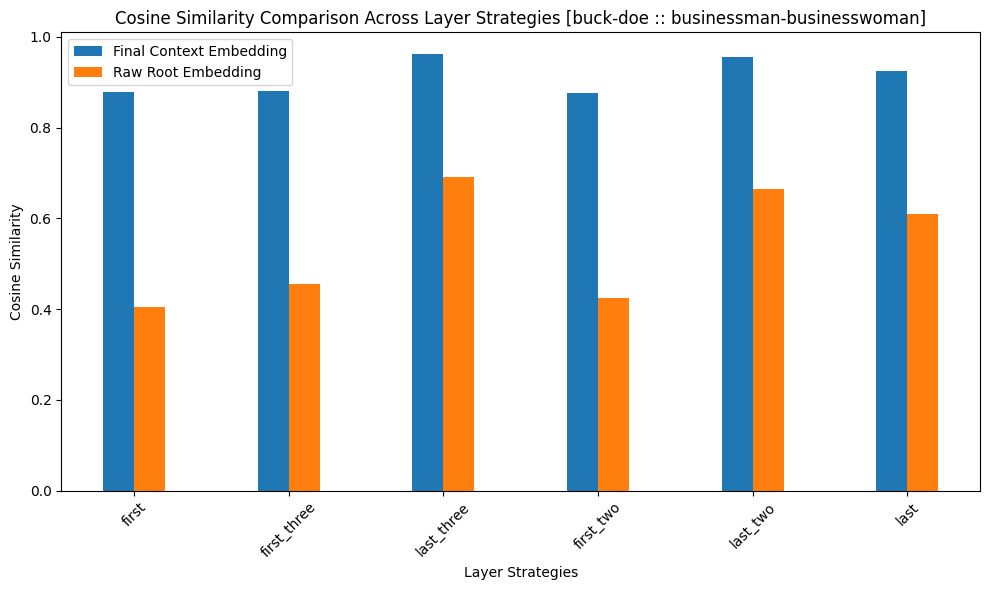

In [316]:
results = run_bats_analogy_test(DF_ctx_emb_actor, DF_ctx_emb_actress,
                      DF_ctx_emb_batman, DF_ctx_emb_batwoman)


# Plotting cosine similarities for all strategies as a bar chart:
title = f'Cosine Similarity Comparison Across Layer Strategies [{a}-{b} :: {c}-{d}]'
plot_cosine_similarities(results, title)

---
# The Individual Tests seems to show good Results? Let me try on a larger batch

## 1. Still doing `Encyclopedic_semantics` -> `E10 [male - female].txt`

In [317]:
PATH_context_forest = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS/female-male-batch/FINAL_EMB_drugs"
context_forest_data_batch2 = load_final_ctx_emb_dataset(PATH_context_forest)

In [318]:
# I'll need a generic function to create dataframes for testing from provided 

# TODO: Need to do this. I ran out of time this week